

### Overview
This notebook implements and compares 4 baseline experiments:

| Experiment | Features | Classifier |
|------------|----------|------------|
| E1 | Log-Mel (256-dim) | kNN |
| E2 | Log-Mel (256-dim) | SVM |
| E3 | MFCC (80-dim) | kNN |
| E4 | MFCC (80-dim) | SVM |




## 1. Install Dependencies


In [1]:
import sys
!{sys.executable} -m pip install scikit-learn librosa==0.11.0 tqdm numpy pandas matplotlib seaborn --quiet



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and Setup


In [ ]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SR      = 22050
N_MELS  = 128
N_FFT   = 2048
HOP_LEN = 512
FMIN    = 20
FMAX    = 8000
N_MFCC  = 40

CLASSES = [
    'bus', 'busystreet', 'office', 'openairmarket', 'park',
    'quietstreet', 'restaurant', 'supermarket', 'tube', 'tubestation'
]
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}

OUTPUT_DIR = 'output_block1'

print('Setup complete.')


Setup complete.


## 3. Load Features from Block 2




In [3]:
logmel_data = np.load(os.path.join(OUTPUT_DIR, 'features_logmel.npz'))
X_logmel_train = logmel_data['X_train']
X_logmel_val   = logmel_data['X_val']
y_train        = logmel_data['y_train']
y_val          = logmel_data['y_val']

mfcc_data = np.load(os.path.join(OUTPUT_DIR, 'features_mfcc.npz'))
X_mfcc_train = mfcc_data['X_train']
X_mfcc_val   = mfcc_data['X_val']

with open(os.path.join(OUTPUT_DIR, 'scaler_logmel.pkl'), 'rb') as f:
    scaler_logmel = pickle.load(f)

with open(os.path.join(OUTPUT_DIR, 'scaler_mfcc.pkl'), 'rb') as f:
    scaler_mfcc = pickle.load(f)

print('Features loaded successfully.')
print(f'X_logmel_train : {X_logmel_train.shape}')
print(f'X_logmel_val   : {X_logmel_val.shape}')
print(f'X_mfcc_train   : {X_mfcc_train.shape}')
print(f'X_mfcc_val     : {X_mfcc_val.shape}')
print(f'y_train dist   : {np.bincount(y_train)}')
print(f'y_val dist     : {np.bincount(y_val)}')


Features loaded successfully.
X_logmel_train : (80, 256)
X_logmel_val   : (20, 256)
X_mfcc_train   : (80, 80)
X_mfcc_val     : (20, 80)
y_train dist   : [8 8 8 8 8 8 8 8 8 8]
y_val dist     : [2 2 2 2 2 2 2 2 2 2]


## 4. Helper Functions


In [4]:
def evaluate_model(model, X_train, X_val, y_train, y_val, experiment_name):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_val_pred   = model.predict(X_val)
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc   = accuracy_score(y_val, y_val_pred)
    val_f1    = f1_score(y_val, y_val_pred, average='macro')
    print(f'\n{"=" * 50}')
    print(f'Experiment: {experiment_name}')
    print(f'{"=" * 50}')
    print(f'  Train accuracy       : {train_acc:.4f}')
    print(f'  Validation accuracy  : {val_acc:.4f}')
    print(f'  Validation F1 (macro): {val_f1:.4f}')
    print(f'  Overfitting gap      : {train_acc - val_acc:.4f}')
    return {
        'name'      : experiment_name,
        'model'     : model,
        'train_acc' : train_acc,
        'val_acc'   : val_acc,
        'val_f1'    : val_f1,
        'y_val_pred': y_val_pred,
        'y_val_true': y_val
    }


def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(CLASSES, fontsize=7)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)


print('Helper functions defined.')


Helper functions defined.


## 5. Experiment E1 — Log-Mel + kNN



In [5]:
knn_logmel = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')

results_E1 = evaluate_model(
    knn_logmel, X_logmel_train, X_logmel_val, y_train, y_val,
    experiment_name='E1 — Log-Mel + kNN'
)

print('\nDetailed classification report (validation set):')
print(classification_report(y_val, results_E1['y_val_pred'], target_names=CLASSES))



Experiment: E1 — Log-Mel + kNN
  Train accuracy       : 1.0000
  Validation accuracy  : 0.3000
  Validation F1 (macro): 0.2805
  Overfitting gap      : 0.7000

Detailed classification report (validation set):
               precision    recall  f1-score   support

          bus       0.33      0.50      0.40         2
   busystreet       1.00      0.50      0.67         2
       office       0.00      0.00      0.00         2
openairmarket       0.50      0.50      0.50         2
         park       0.00      0.00      0.00         2
  quietstreet       0.00      0.00      0.00         2
   restaurant       0.40      1.00      0.57         2
  supermarket       0.00      0.00      0.00         2
         tube       0.00      0.00      0.00         2
  tubestation       1.00      0.50      0.67         2

     accuracy                           0.30        20
    macro avg       0.32      0.30      0.28        20
 weighted avg       0.32      0.30      0.28        20



## 6. Experiment E2 — Log-Mel + SVM




In [6]:
svm_logmel = SVC(kernel='rbf', C=10, gamma='scale',
                 decision_function_shape='ovr', random_state=RANDOM_STATE)

results_E2 = evaluate_model(
    svm_logmel, X_logmel_train, X_logmel_val, y_train, y_val,
    experiment_name='E2 — Log-Mel + SVM'
)

print('\nDetailed classification report (validation set):')
print(classification_report(y_val, results_E2['y_val_pred'], target_names=CLASSES))



Experiment: E2 — Log-Mel + SVM
  Train accuracy       : 0.9875
  Validation accuracy  : 0.6000
  Validation F1 (macro): 0.5667
  Overfitting gap      : 0.3875

Detailed classification report (validation set):
               precision    recall  f1-score   support

          bus       0.67      1.00      0.80         2
   busystreet       1.00      0.50      0.67         2
       office       0.67      1.00      0.80         2
openairmarket       1.00      1.00      1.00         2
         park       0.50      0.50      0.50         2
  quietstreet       0.00      0.00      0.00         2
   restaurant       0.50      0.50      0.50         2
  supermarket       0.50      0.50      0.50         2
         tube       0.33      0.50      0.40         2
  tubestation       0.50      0.50      0.50         2

     accuracy                           0.60        20
    macro avg       0.57      0.60      0.57        20
 weighted avg       0.57      0.60      0.57        20



## 7. Experiment E3 — MFCC + kNN


In [7]:
knn_mfcc = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')

results_E3 = evaluate_model(
    knn_mfcc, X_mfcc_train, X_mfcc_val, y_train, y_val,
    experiment_name='E3 — MFCC + kNN'
)

print('\nDetailed classification report (validation set):')
print(classification_report(y_val, results_E3['y_val_pred'], target_names=CLASSES))



Experiment: E3 — MFCC + kNN
  Train accuracy       : 1.0000
  Validation accuracy  : 0.5500
  Validation F1 (macro): 0.5319
  Overfitting gap      : 0.4500

Detailed classification report (validation set):
               precision    recall  f1-score   support

          bus       1.00      1.00      1.00         2
   busystreet       0.67      1.00      0.80         2
       office       0.00      0.00      0.00         2
openairmarket       0.20      0.50      0.29         2
         park       0.50      0.50      0.50         2
  quietstreet       1.00      1.00      1.00         2
   restaurant       0.33      0.50      0.40         2
  supermarket       1.00      0.50      0.67         2
         tube       0.00      0.00      0.00         2
  tubestation       1.00      0.50      0.67         2

     accuracy                           0.55        20
    macro avg       0.57      0.55      0.53        20
 weighted avg       0.57      0.55      0.53        20



## 8. Experiment E4 — MFCC + SVM


In [8]:
svm_mfcc = SVC(kernel='rbf', C=10, gamma='scale',
               decision_function_shape='ovr', random_state=RANDOM_STATE)

results_E4 = evaluate_model(
    svm_mfcc, X_mfcc_train, X_mfcc_val, y_train, y_val,
    experiment_name='E4 — MFCC + SVM'
)

print('\nDetailed classification report (validation set):')
print(classification_report(y_val, results_E4['y_val_pred'], target_names=CLASSES))



Experiment: E4 — MFCC + SVM
  Train accuracy       : 1.0000
  Validation accuracy  : 0.5500
  Validation F1 (macro): 0.5300
  Overfitting gap      : 0.4500

Detailed classification report (validation set):
               precision    recall  f1-score   support

          bus       1.00      1.00      1.00         2
   busystreet       1.00      0.50      0.67         2
       office       1.00      0.50      0.67         2
openairmarket       0.00      0.00      0.00         2
         park       0.50      0.50      0.50         2
  quietstreet       0.50      0.50      0.50         2
   restaurant       0.50      1.00      0.67         2
  supermarket       0.67      1.00      0.80         2
         tube       0.00      0.00      0.00         2
  tubestation       0.50      0.50      0.50         2

     accuracy                           0.55        20
    macro avg       0.57      0.55      0.53        20
 weighted avg       0.57      0.55      0.53        20



## 9. Comparative Results Table




In [9]:
all_results = [results_E1, results_E2, results_E3, results_E4]

summary = pd.DataFrame([
    {
        'Experiment'    : r['name'],
        'Train Acc'     : f"{r['train_acc']:.4f}",
        'Val Acc'       : f"{r['val_acc']:.4f}",
        'Val F1 (macro)': f"{r['val_f1']:.4f}",
        'Overfit Gap'   : f"{r['train_acc'] - r['val_acc']:.4f}"
    }
    for r in all_results
])

print('=' * 75)
print('BASELINE EXPERIMENTS — COMPARATIVE RESULTS (Validation Set)')
print('=' * 75)
print(summary.to_string(index=False))
print('=' * 75)

best_idx = np.argmax([r['val_acc'] for r in all_results])
print(f'\nBest experiment  : {all_results[best_idx]["name"]}')
print(f'Best val accuracy: {all_results[best_idx]["val_acc"]:.4f}')


BASELINE EXPERIMENTS — COMPARATIVE RESULTS (Validation Set)
        Experiment Train Acc Val Acc Val F1 (macro) Overfit Gap
E1 — Log-Mel + kNN    1.0000  0.3000         0.2805      0.7000
E2 — Log-Mel + SVM    0.9875  0.6000         0.5667      0.3875
   E3 — MFCC + kNN    1.0000  0.5500         0.5319      0.4500
   E4 — MFCC + SVM    1.0000  0.5500         0.5300      0.4500

Best experiment  : E2 — Log-Mel + SVM
Best val accuracy: 0.6000


## 10. Visual Comparison — Bar Chart


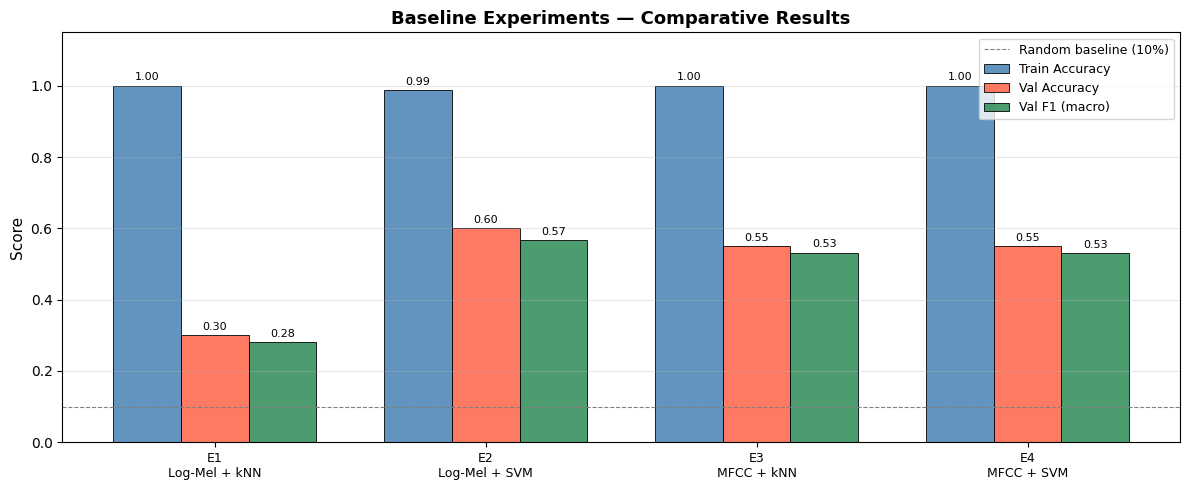

Saved: output_block1\baseline_comparison.png


In [10]:
exp_names  = [r['name'].replace(' — ', '\n') for r in all_results]
train_accs = [r['train_acc'] for r in all_results]
val_accs   = [r['val_acc']   for r in all_results]
val_f1s    = [r['val_f1']    for r in all_results]

x = np.arange(len(all_results))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width, train_accs, width, label='Train Accuracy',
               color='steelblue', edgecolor='black', linewidth=0.7, alpha=0.85)
bars2 = ax.bar(x,          val_accs,  width, label='Val Accuracy',
               color='tomato',    edgecolor='black', linewidth=0.7, alpha=0.85)
bars3 = ax.bar(x + width,  val_f1s,   width, label='Val F1 (macro)',
               color='seagreen',  edgecolor='black', linewidth=0.7, alpha=0.85)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Baseline Experiments — Comparative Results', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(exp_names, fontsize=9)
ax.set_ylim(0, 1.15)
ax.axhline(0.1, color='gray', linestyle='--', linewidth=0.8, label='Random baseline (10%)')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'baseline_comparison.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')


## 11. Confusion Matrices — All 4 Experiments



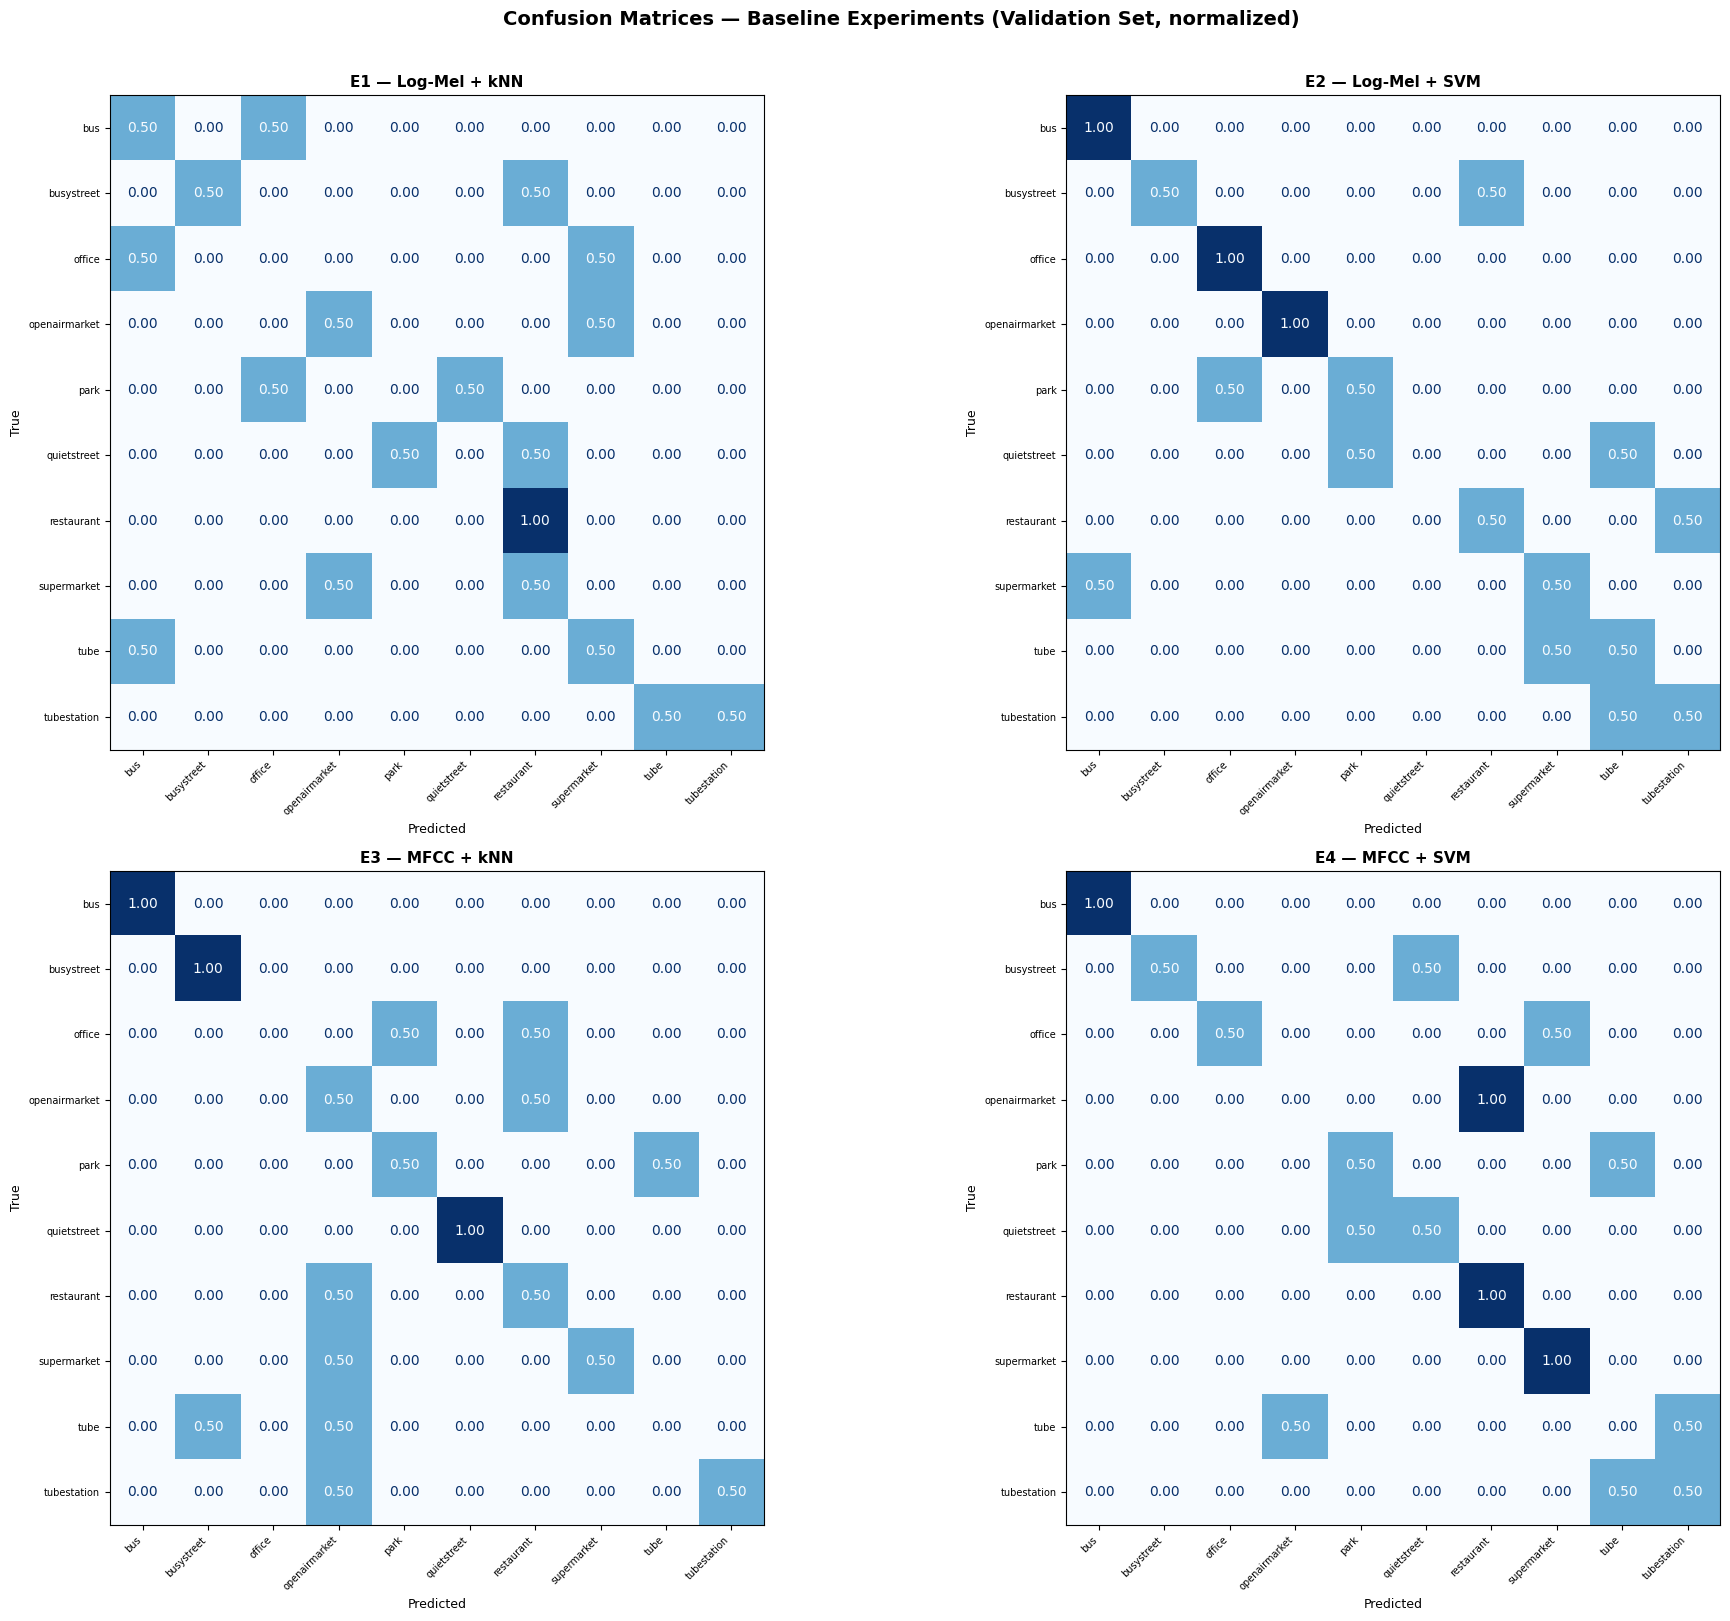

Saved: output_block1\confusion_matrices_baseline.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, result in enumerate(all_results):
    plot_confusion_matrix(
        result['y_val_true'], result['y_val_pred'],
        title=result['name'], ax=axes[i]
    )

fig.suptitle('Confusion Matrices — Baseline Experiments (Validation Set, normalized)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'confusion_matrices_baseline.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')


## 12. Per-Class Analysis — Best Experiment




Per-class results — E2 — Log-Mel + SVM
               precision  recall  f1-score
bus                0.667     1.0     0.800
busystreet         1.000     0.5     0.667
office             0.667     1.0     0.800
openairmarket      1.000     1.0     1.000
park               0.500     0.5     0.500
quietstreet        0.000     0.0     0.000
restaurant         0.500     0.5     0.500
supermarket        0.500     0.5     0.500
tube               0.333     0.5     0.400
tubestation        0.500     0.5     0.500


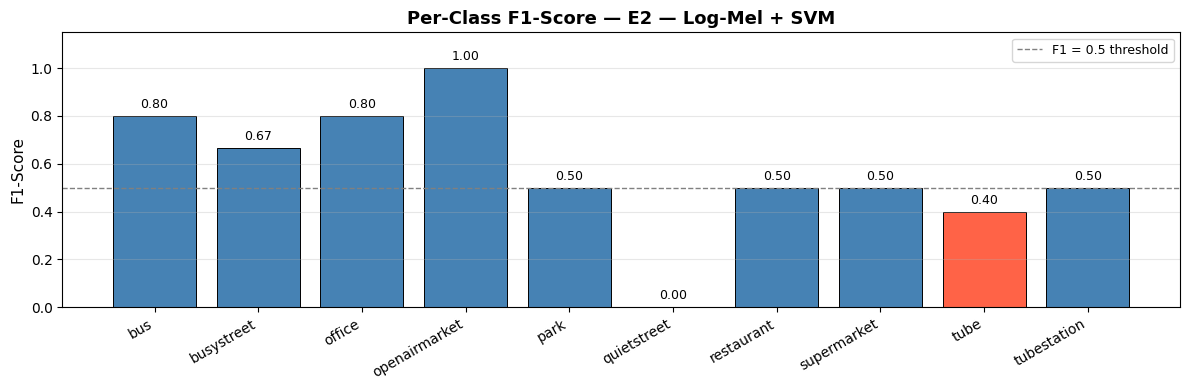

Saved: output_block1\perclass_f1_best.png

Hardest classes (F1 < 0.5):
             precision  recall  f1-score
quietstreet      0.000     0.0       0.0
tube             0.333     0.5       0.4


In [12]:
best_result = all_results[best_idx]

report = classification_report(
    best_result['y_val_true'], best_result['y_val_pred'],
    target_names=CLASSES, output_dict=True
)
df_report = pd.DataFrame(report).T.loc[CLASSES, ['precision', 'recall', 'f1-score']]
df_report = df_report.astype(float).round(3)

print(f'Per-class results — {best_result["name"]}')
print(df_report.to_string())

fig, ax = plt.subplots(figsize=(12, 4))
colors_bar = ['tomato' if v < 0.5 else 'steelblue' for v in df_report['f1-score']]
bars = ax.bar(df_report.index, df_report['f1-score'],
              color=colors_bar, edgecolor='black', linewidth=0.7)

for bar, val in zip(bars, df_report['f1-score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_title(f'Per-Class F1-Score — {best_result["name"]}', fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='F1 = 0.5 threshold')
ax.legend(fontsize=9)
plt.xticks(rotation=30, ha='right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'perclass_f1_best.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

print('\nHardest classes (F1 < 0.5):')
hard = df_report[df_report['f1-score'] < 0.5]
print(hard if len(hard) > 0 else '  All classes above F1 = 0.5')


## 13. Final Evaluation on Official Test Set




In [ ]:
TEST_PATH = r'C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Integracion tecnologias\Proyecto\scenes_stereo_testset' 

def preprocess_audio(filepath, sr=SR):
    wav, _ = librosa.load(filepath, sr=sr, mono=True)
    wav = wav / (np.max(np.abs(wav)) + 1e-9)
    return wav

def extract_logmel_features(wav):
    mel = librosa.feature.melspectrogram(
        y=wav, sr=SR, n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LEN, fmin=FMIN, fmax=FMAX
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    return np.concatenate([np.mean(log_mel, axis=1), np.std(log_mel, axis=1)])

def extract_mfcc_features(wav):
    mfcc = librosa.feature.mfcc(
        y=wav, sr=SR, n_mfcc=N_MFCC, n_fft=N_FFT,
        hop_length=HOP_LEN, fmin=FMIN, fmax=FMAX
    )
    return np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)])

# Construir anotaciones del test set
test_records = []
for filename in sorted(os.listdir(TEST_PATH)):
    if not filename.endswith('.wav'):
        continue
    label = re.sub(r'\d+$', '', os.path.splitext(filename)[0])
    if label not in CLASS_TO_IDX:
        print(f'WARNING: Unknown label "{label}" — skipping {filename}')
        continue
    test_records.append({
        'filename' : filename,
        'filepath' : os.path.join(TEST_PATH, filename),
        'label'    : label,
        'label_idx': CLASS_TO_IDX[label]
    })

df_test = pd.DataFrame(test_records)
print(f'Test files found: {len(df_test)}')
print(df_test['label'].value_counts().sort_index())


Test files found: 100
label
bus              10
busystreet       10
office           10
openairmarket    10
park             10
quietstreet      10
restaurant       10
supermarket      10
tube             10
tubestation      10
Name: count, dtype: int64


In [ ]:
# Extraer features del test set
X_logmel_test_raw, X_mfcc_test_raw, y_test = [], [], []

for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc='Extracting test features'):
    wav = preprocess_audio(row['filepath'])
    X_logmel_test_raw.append(extract_logmel_features(wav))
    X_mfcc_test_raw.append(extract_mfcc_features(wav))
    y_test.append(row['label_idx'])

X_logmel_test_raw = np.array(X_logmel_test_raw)
X_mfcc_test_raw   = np.array(X_mfcc_test_raw)
y_test            = np.array(y_test)

# Aplicar scalers del train 
X_logmel_test = scaler_logmel.transform(X_logmel_test_raw)
X_mfcc_test   = scaler_mfcc.transform(X_mfcc_test_raw)

print(f'X_logmel_test : {X_logmel_test.shape}')
print(f'X_mfcc_test   : {X_mfcc_test.shape}')
print(f'y_test dist   : {np.bincount(y_test)}')


Extracting test features: 100%|██████████| 100/100 [00:38<00:00,  2.58it/s]

X_logmel_test : (100, 256)
X_mfcc_test   : (100, 80)
y_test dist   : [10 10 10 10 10 10 10 10 10 10]


In [15]:
test_X = {
    'E1 — Log-Mel + kNN': X_logmel_test,
    'E2 — Log-Mel + SVM': X_logmel_test,
    'E3 — MFCC + kNN'   : X_mfcc_test,
    'E4 — MFCC + SVM'   : X_mfcc_test,
}

print('=' * 65)
print('FINAL RESULTS — OFFICIAL TEST SET')
print('=' * 65)
print(f'{"Experiment":<25} {"Val Acc":>10} {"Test Acc":>10} {"Test F1":>10}')
print('-' * 65)

test_results = []
for result in all_results:
    X_t = test_X[result['name']]
    y_test_pred = result['model'].predict(X_t)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1  = f1_score(y_test, y_test_pred, average='macro')
    test_results.append({
        **result,
        'test_acc'   : test_acc,
        'test_f1'    : test_f1,
        'y_test_pred': y_test_pred,
        'y_test_true': y_test
    })
    print(f"{result['name']:<25} {result['val_acc']:>10.4f} {test_acc:>10.4f} {test_f1:>10.4f}")

print('=' * 65)
best_test_idx = np.argmax([r['test_acc'] for r in test_results])
print(f'\nBest on test set : {test_results[best_test_idx]["name"]}')
print(f'Test accuracy    : {test_results[best_test_idx]["test_acc"]:.4f}')


FINAL RESULTS — OFFICIAL TEST SET
Experiment                   Val Acc   Test Acc    Test F1
-----------------------------------------------------------------
E1 — Log-Mel + kNN            0.3000     0.4000     0.3804
E2 — Log-Mel + SVM            0.6000     0.5900     0.5740
E3 — MFCC + kNN               0.5500     0.6000     0.5946
E4 — MFCC + SVM               0.5500     0.7500     0.7404

Best on test set : E4 — MFCC + SVM
Test accuracy    : 0.7500


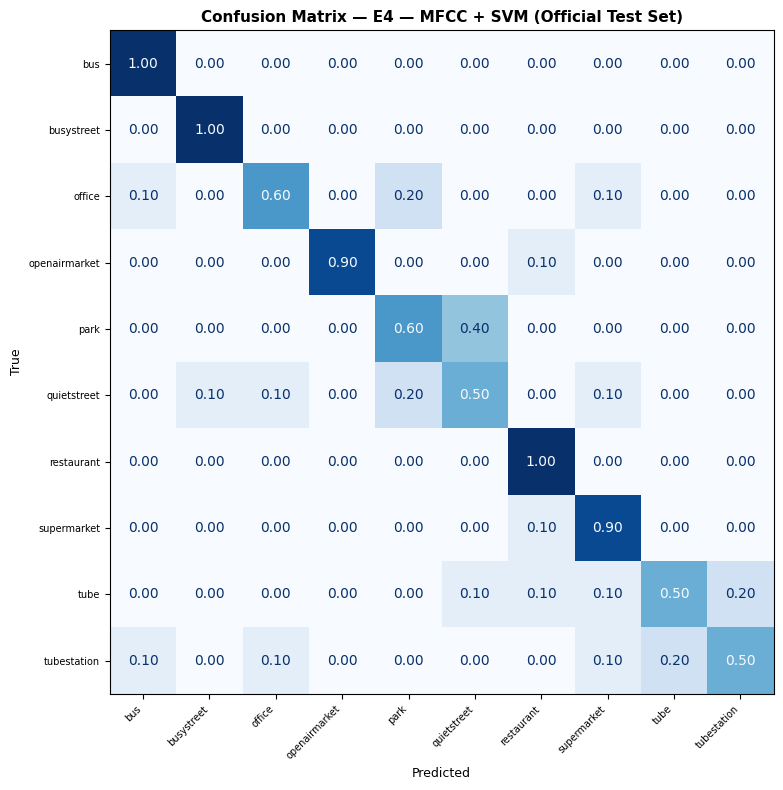


Detailed report — best model on test set:
               precision    recall  f1-score   support

          bus       0.83      1.00      0.91        10
   busystreet       0.91      1.00      0.95        10
       office       0.75      0.60      0.67        10
openairmarket       1.00      0.90      0.95        10
         park       0.60      0.60      0.60        10
  quietstreet       0.50      0.50      0.50        10
   restaurant       0.77      1.00      0.87        10
  supermarket       0.69      0.90      0.78        10
         tube       0.71      0.50      0.59        10
  tubestation       0.71      0.50      0.59        10

     accuracy                           0.75       100
    macro avg       0.75      0.75      0.74       100
 weighted avg       0.75      0.75      0.74       100



In [16]:
best_test = test_results[best_test_idx]

fig, ax = plt.subplots(figsize=(10, 8))
plot_confusion_matrix(
    best_test['y_test_true'], best_test['y_test_pred'],
    title=f'Confusion Matrix — {best_test["name"]} (Official Test Set)',
    ax=ax
)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'confusion_matrix_best_test.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

print('\nDetailed report — best model on test set:')
print(classification_report(
    best_test['y_test_true'], best_test['y_test_pred'], target_names=CLASSES
))


## 14. Save Best Model


In [17]:
with open(os.path.join(OUTPUT_DIR, 'best_baseline_model.pkl'), 'wb') as f:
    pickle.dump(best_test['model'], f)

np.savez(
    os.path.join(OUTPUT_DIR, 'features_logmel_test.npz'),
    X_test=X_logmel_test,
    y_test=y_test
)

print('Saved to', OUTPUT_DIR)
print('  best_baseline_model.pkl')
print('  features_logmel_test.npz')


Saved to output_block1
  best_baseline_model.pkl
  features_logmel_test.npz
